In [6]:
#Importo as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#Carrego os arquivos de dados
dfVendas = pd.read_csv("dfVendas.csv", delimiter= ",")
dfVendasExtras = pd.read_csv("dfVendasExtras.csv", delimiter= ",")
dfCampanhas = pd.read_csv("campanhas_corrigido.csv", delimiter= ",")

In [8]:
#Concateno os arquivos de Vendas
dfVendasTotal = pd.concat([dfVendas, dfVendasExtras], ignore_index=True)
dfVendasTotal

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal,Valor_Total,ID_Campanha
0,1,350,45,2022-09-23,4,Online,5795.64,17
1,2,925,68,2024-02-09,1,Loja Física,4614.41,16
2,3,915,75,2022-09-11,4,Online,2057.48,17
3,4,494,47,2024-05-10,4,Loja Física,12864.44,9
4,5,523,79,2023-10-15,4,Loja Física,13317.28,5
...,...,...,...,...,...,...,...,...
23995,23996,99,68,2024-11-06,2,Online,9228.82,10
23996,23997,225,90,2024-10-14,2,Loja Física,6536.63,20
23997,23998,974,15,2024-12-29,4,Loja Física,12565.21,6
23998,23999,269,44,2025-06-13,3,Loja Física,9834.99,15


In [9]:
#Realizo o merge entre os dataFrames
dfVendasCampanhas = pd.merge(dfVendasTotal, dfCampanhas, left_on="ID_Campanha", right_on="ID_Campanha", how="inner")
dfVendasCampanhas.head(2)

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal_x,Valor_Total,ID_Campanha,Canal_y,Data_Inicio,Data_Fim,Tipo_Campanha,Custo
0,1,350,45,2022-09-23,4,Online,5795.64,17,Online,2022-07-24,2022-09-29,Desconto,5034.61
1,2,925,68,2024-02-09,1,Loja Física,4614.41,16,Impressos,2024-01-19,2024-03-26,Lançamento,2239.48


In [10]:
dfValorTotalCampanha = dfVendasCampanhas.groupby("ID_Campanha")["Valor_Total"].sum().reset_index()
dfValorTotalCampanha

,ID_Campanha,Valor_Total
0,1,5160796.83
1,2,10587513.00
2,3,9960534.91
3,4,9788116.49
4,5,10850322.51
5,6,4968024.06
6,7,10089807.57
7,8,10581288.50
8,9,9947377.75
9,10,4962584.98


In [11]:
#Cria o array com os dados do total de vendas por campanha
arrayValorTotalCampanha = np.array(dfValorTotalCampanha["Valor_Total"])
arrayValorTotalCampanha

array([ 5160796.83, 10587513.  ,  9960534.91,  9788116.49, 10850322.51,
        4968024.06, 10089807.57, 10581288.5 ,  9947377.75,  4962584.98,
       10853593.63,  9530646.41,  5195112.53,  9847774.1 ,  5009118.9 ,
       10483962.09,  9261567.66, 10338544.39, 10129802.13,  8518307.79])

In [49]:
#Cálculos estatísticos
media = np.mean(arrayValorTotalCampanha)
mediana = np.median(arrayValorTotalCampanha)
q1 = np.percentile(arrayValorTotalCampanha, 25)
q2 = np.percentile(arrayValorTotalCampanha, 50)
q3 = np.percentile(arrayValorTotalCampanha, 75)
distancia = (media - mediana) / mediana
iqr = q3 - q1
limSuperior = q3 + (1.5 * iqr)
limInferior = q1 - (1.5 * iqr)
variancia = np.var(arrayValorTotalCampanha)
desvio_padrao = np.std(arrayValorTotalCampanha)
coeficiente_variacao = (desvio_padrao / media) * 100
distancia_variancia = (variancia / (media ** 2)) * 100
minimo = np.min(arrayValorTotalCampanha)
maximo = np.max(arrayValorTotalCampanha)
amplitude = maximo - minimo

print(f'Média     = {media:,.2f}')
print(f'Mediana   = {mediana:,.2f}')
print(f'Q1        = {q1:,.2f}')
print(f'Q2        = {q2:,.2f}')
print(f'Q3        = {q3:,.2f}')
print(f'Distância = {distancia * 100:.2f} %')
print(f'Lim. Sup. = {limSuperior:,.2f}')
print(f'Lim. Inf. = {limInferior:,.2f}')
print(f'Variância: {variancia:,.2f}')
print(f'Desvio padrão: {desvio_padrao:,.2f}')
print(f'Coeficiente de variação: {coeficiente_variacao:,.2f} %')
print(f'Distância da variância em relação à média: {distancia_variancia:,.2f} %')
print(f"Máximo: {maximo:,.2f}")
print(f"Mínimo: {minimo:,.2f}")
print(f"Amplitude: {amplitude:,.2f}")

Média     = 8,803,239.81
Mediana   = 9,897,575.93
Q1        = 7,687,508.98
Q2        = 9,897,575.93
Q3        = 10,374,898.82
Distância = -11.06 %
Lim. Sup. = 14,405,983.58
Lim. Inf. = 3,656,424.21
Variância: 4,950,361,140,260.03
Desvio padrão: 2,224,940.70
Coeficiente de variação: 25.27 %
Distância da variância em relação à média: 6.39 %
Máximo: 10,853,593.63
Mínimo: 4,962,584.98
Amplitude: 5,891,008.65


In [14]:
#Crio um dataFrame com os outliers superiores
dfOutlierSuperior = dfValorTotalCampanha.loc[dfValorTotalCampanha["Valor_Total"] >= limSuperior]
dfOutlierSuperior

,ID_Campanha,Valor_Total


In [16]:
#Crio um dataFrame com os outliers inferiores
dfOutlierInferior = dfValorTotalCampanha.loc[dfValorTotalCampanha["Valor_Total"] <= limInferior]
dfOutlierInferior

,ID_Campanha,Valor_Total


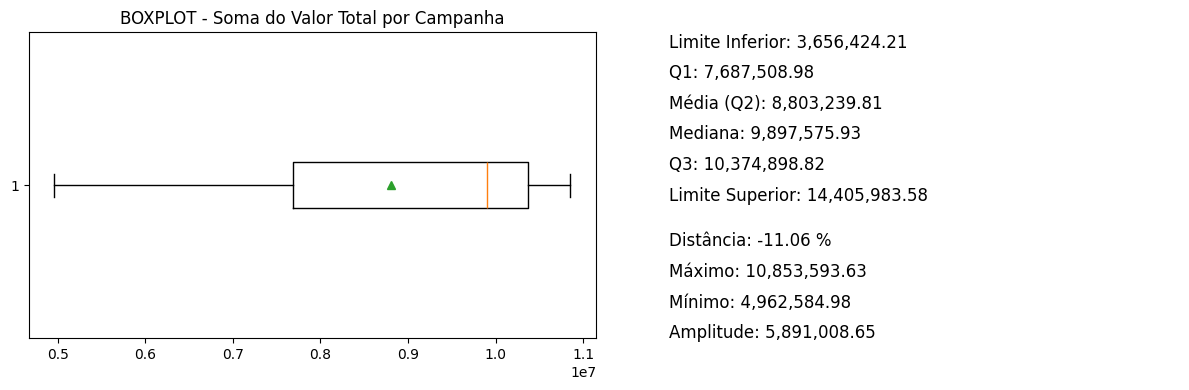

In [43]:
#Cria uma figura com 2 áreas de gráficos (1 linha x 2 colunas)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

#Gráfico 1: Linha - Vendas por dia da semana
axs[0].boxplot(arrayValorTotalCampanha, vert=False, showmeans=True)
axs[0].set_title('BOXPLOT - Soma do Valor Total por Campanha')

#Gráfico 4: Quadro de texto explicativo
axs[1].axis('off')    #Desativa os eixos para poder incluir texto
axs[1].text(0.10, 0.95, f'Limite Inferior: {limInferior:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.85, f'Q1: {q1:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.75, f'Média (Q2): {media:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.65, f'Mediana: {mediana:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.55, f'Q3: {q3:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.45, f'Limite Superior: {limSuperior:,.2f}', fontsize=12, color='black')

axs[1].text(0.10, 0.30, f'Distância: {distancia*100:,.2f} %', fontsize=12, color='black')
axs[1].text(0.10, 0.20, f'Máximo: {maximo:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.10, f'Mínimo: {minimo:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.00, f'Amplitude: {amplitude:,.2f}', fontsize=12, color='black')

#Ajusta os espaços entre os gráficos para evitar sobreposição
plt.tight_layout()

#Exibe todos os gráficos
plt.show()